In [3]:
# Case 5: Global prisoptimal drift med hensyn til vannverdi

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import milp, LinearConstraint, Bounds
from scipy.sparse import lil_matrix


# 1) Laster inn Excel-fil med spotpriser per time

df = pd.read_excel("Pris_2025.xlsx", engine="openpyxl")

df = df.rename(columns={
    "Dato, time": "Tid",
    "Gjennomsnitt Pris (øre/kWh)": "Pris_ore_kWh"
})

df["Tid"] = pd.to_datetime(df["Tid"])
df["Pris_ore_kWh"] = pd.to_numeric(df["Pris_ore_kWh"], errors="coerce")

df = df.dropna(subset=["Tid", "Pris_ore_kWh"]).copy()
df = df.sort_values("Tid").reset_index(drop=True)

antall_timer = len(df)
priser = df["Pris_ore_kWh"].to_numpy()


# Fyller inn manglende timer i prisfilen ved interpolasjon

full_tid = pd.date_range(
    start="2025-01-01 00:00:00",
    end="2025-12-31 23:00:00",
    freq="h"
)

df = df.set_index("Tid").reindex(full_tid)

df["Pris_ore_kWh"] = df["Pris_ore_kWh"].interpolate()

df = df.reset_index().rename(columns={"index": "Tid"})

antall_timer = len(df)
priser = df["Pris_ore_kWh"].to_numpy()


# Tilsig basert på Case 1

aarlig_tilsig_m3 = 139.113e6  # m³/år 

fordelingsfaktorer = np.array([
    0.3, 0.3, 0.4, 1.5, 2.5, 1.4,
    0.7, 0.7, 1.0, 1.4, 1.2, 0.6
])

dager_per_maaned = np.array([31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31])
timer_per_maaned = dager_per_maaned * 24

# Fordel årsvolumet på måneder
maanedsvolum = aarlig_tilsig_m3 * fordelingsfaktorer / fordelingsfaktorer.sum()

# m³/time per måned
tilsig_per_maaned_h = maanedsvolum / timer_per_maaned

# Timeserie med tilsig
tilsig_timevis = np.repeat(tilsig_per_maaned_h, timer_per_maaned)

# Tilpass lengde til datasettet
tilsig_timevis = tilsig_timevis[:len(df)]


print("Årlig tilsig:", tilsig_timevis.sum() / 1e6, "millioner m³/år")
print("Gjennomsnittlig tilsig:", np.mean(tilsig_timevis), "m³/t")
print("Min tilsig:", np.min(tilsig_timevis), "m³/t")
print("Maks tilsig:", np.max(tilsig_timevis), "m³/t")


# 2) Magasin

Vmax = 94.5e6     # m^3 
Vmin = 0.50e6
  
start_fyllingsgrad = 0.92        # startnivå: 92 % 
slutt_fyllingsgrad_min = 0.66    # sluttnivå: 66 % 
slutt_fyllingsgrad_max = 0.92

V0 = start_fyllingsgrad * Vmax          
V_slutt_min = slutt_fyllingsgrad_min * Vmax
V_slutt_max = slutt_fyllingsgrad_max * Vmax


# 3) Parametere

rho = 1000        # kg/m^3
g = 9.81          # m/s^2
H_brutto = 655    # m
Q_max_1 = 10.7    # m^3/s
Q_max_2 = 16.05 
Q_max_3 = 21.4

Q2_trykkror_eksisterende = Q_max_2 * (2 / 3)
Q2_trykkror_nytt = Q_max_2 * (1 / 3)
Q3_trykkror_eksisterende = Q_max_3 * 0.5
Q3_trykkror_nytt = Q_max_3 * 0.5

eta_generator = 0.99
eta_transformator = 0.99

# Driftstunnel 1
driftstunnel_1_L = 900      # m
driftstunnel_1_tverr = 9    # m^2

# Driftstunnel 2
driftstunnel_2_L = 1400
driftstunnel_2_tverr = 17

# Trykksjakt
trykksjakt_L = 550
trykksjakt_tverr = 5

# Overgang
overgang_L = 200
overgang_tverr = 15

# Trykkrør
trykkror_L = 100
trykkror_tverr = 2
# Ekstra parallelle trykkrør ved utvidelser ved 90 og 120 MW
trykkror_tverr_nytt_Q2 = 1   
trykkror_tverr_nytt_Q3 = 2   

# Utløp
utlop_L = 1200
utlop_tverr = 10.5
# Økt tverrsnitt for utløp i utbyggingsscenario ved 120 MW
utlop_tverr_Q3 = utlop_tverr * 2



# Hydraulisk radius
# R_h = D/4 fra R_h = A/P, der A = πD^2/4 og P = πD

D_driftstunnel_1 = np.sqrt(4 * driftstunnel_1_tverr / np.pi)
R_h_driftstunnel_1 = D_driftstunnel_1 / 4

D_driftstunnel_2 = np.sqrt(4 * driftstunnel_2_tverr / np.pi)
R_h_driftstunnel_2 = D_driftstunnel_2 / 4

D_trykksjakt = np.sqrt(4 * trykksjakt_tverr / np.pi)
R_h_trykksjakt = D_trykksjakt / 4

D_overgang = np.sqrt(4 * overgang_tverr / np.pi)
R_h_overgang = D_overgang / 4

# Trykkrør eksisterende
D_trykkror = np.sqrt(4 * trykkror_tverr / np.pi)
R_h_trykkror  = D_trykkror / 4
# Nytt trykkrør ved 90 MW
D_trykkror_nytt_Q2 = np.sqrt(4 * trykkror_tverr_nytt_Q2 / np.pi)
R_h_trykkror_nytt_Q2 = D_trykkror_nytt_Q2 / 4
# Nytt trykkrør ved 120 MW
D_trykkror_nytt_Q3 = np.sqrt(4 * trykkror_tverr_nytt_Q3 / np.pi)
R_h_trykkror_nytt_Q3 = D_trykkror_nytt_Q3 / 4

D_utlop = np.sqrt(4 * utlop_tverr / np.pi)
R_h_utlop = D_utlop / 4
D_utlop_Q3 = np.sqrt(4 * utlop_tverr_Q3 / np.pi)
R_h_utlop_Q3 = D_utlop_Q3 / 4



# Vannhastigheter

# Hastigheter med Q_1 for alternativ 1 (63 MW)
v1_driftstunnel_1 = Q_max_1 / driftstunnel_1_tverr
v1_driftstunnel_2 = Q_max_1 / driftstunnel_2_tverr
v1_trykksjakt = Q_max_1 / trykksjakt_tverr
v1_overgang = Q_max_1 / overgang_tverr
v1_trykkror  = Q_max_1 / trykkror_tverr
v1_utlop = Q_max_1 / utlop_tverr

# Hastigheter med Q_2 for alternativ 2 (94.5 MW)
v2_driftstunnel_1 = Q_max_2 / driftstunnel_1_tverr
v2_driftstunnel_2 = Q_max_2 / driftstunnel_2_tverr
v2_trykksjakt = Q_max_2 / trykksjakt_tverr
v2_overgang = Q_max_2 / overgang_tverr
v2_trykkror_eksisterende = Q2_trykkror_eksisterende / trykkror_tverr
v2_trykkror_nytt = Q2_trykkror_nytt / trykkror_tverr_nytt_Q2
v2_utlop = Q_max_2 / utlop_tverr

# Hastigheter med Q_3 for alternativ 3 (120.5 MW)
v3_driftstunnel_1 = Q_max_3 / driftstunnel_1_tverr
v3_driftstunnel_2 = Q_max_3 / driftstunnel_2_tverr
v3_trykksjakt = Q_max_3 / trykksjakt_tverr
v3_overgang = Q_max_3 / overgang_tverr
v3_trykkror_eksisterende = Q3_trykkror_eksisterende / trykkror_tverr
v3_trykkror_nytt = Q3_trykkror_nytt / trykkror_tverr_nytt_Q3
v3_utlop = Q_max_3 / utlop_tverr_Q3




# Manning-Strickler ruhetskoeffisienter

M_driftstunnel_1 = 35
M_driftstunnel_2 = 35
M_trykksjakt = 65
M_overgang = 35
M_trykkror = 100
M_utlop = 35


# Falltap fra ved bruk av manningsformel
# h_f = L * v^2 / (M^2 * R_h^(4/3))

# Falltap med Q_1
h_f_driftstunnel_1_Q1 = driftstunnel_1_L * v1_driftstunnel_1**2 / (M_driftstunnel_1**2 * R_h_driftstunnel_1**(4/3))
h_f_driftstunnel_2_Q1 = driftstunnel_2_L * v1_driftstunnel_2**2 / (M_driftstunnel_2**2 * R_h_driftstunnel_2**(4/3))
h_f_trykksjakt_Q1     = trykksjakt_L     * v1_trykksjakt**2     / (M_trykksjakt**2     * R_h_trykksjakt**(4/3))
h_f_overgang_Q1       = overgang_L       * v1_overgang**2       / (M_overgang**2       * R_h_overgang**(4/3))
h_f_trykkror_Q1       = trykkror_L       * v1_trykkror**2       / (M_trykkror**2       * R_h_trykkror**(4/3))
h_f_utlop_Q1          = utlop_L          * v1_utlop**2          / (M_utlop**2          * R_h_utlop**(4/3))

# Falltap med Q_2
h_f_driftstunnel_1_Q2 = driftstunnel_1_L * v2_driftstunnel_1**2        / (M_driftstunnel_1**2 * R_h_driftstunnel_1**(4/3))
h_f_driftstunnel_2_Q2 = driftstunnel_2_L * v2_driftstunnel_2**2        / (M_driftstunnel_2**2 * R_h_driftstunnel_2**(4/3))
h_f_trykksjakt_Q2     = trykksjakt_L     * v2_trykksjakt**2            / (M_trykksjakt**2     * R_h_trykksjakt**(4/3))
h_f_overgang_Q2       = overgang_L       * v2_overgang**2              / (M_overgang**2       * R_h_overgang**(4/3))
h_f_trykkror_Q2_eksisterende = trykkror_L* v2_trykkror_eksisterende**2 / (M_trykkror**2       * R_h_trykkror**(4/3))
h_f_trykkror_Q2_nytt  = trykkror_L       * v2_trykkror_nytt**2         / (M_trykkror**2       * R_h_trykkror_nytt_Q2**(4/3))
h_f_utlop_Q2          = utlop_L          * v2_utlop**2                 / (M_utlop**2          * R_h_utlop**(4/3))

h_f_trykkror_Q2 = (Q2_trykkror_eksisterende / Q_max_2) * h_f_trykkror_Q2_eksisterende + (Q2_trykkror_nytt / Q_max_2) * h_f_trykkror_Q2_nytt

# Falltap med Q_3
h_f_driftstunnel_1_Q3 = driftstunnel_1_L * v3_driftstunnel_1**2        / (M_driftstunnel_1**2 * R_h_driftstunnel_1**(4/3))
h_f_driftstunnel_2_Q3 = driftstunnel_2_L * v3_driftstunnel_2**2        / (M_driftstunnel_2**2 * R_h_driftstunnel_2**(4/3))
h_f_trykksjakt_Q3     = trykksjakt_L     * v3_trykksjakt**2            / (M_trykksjakt**2     * R_h_trykksjakt**(4/3))
h_f_overgang_Q3       = overgang_L       * v3_overgang**2              / (M_overgang**2       * R_h_overgang**(4/3))
h_f_trykkror_Q3_eksisterende = trykkror_L* v3_trykkror_eksisterende**2 / (M_trykkror**2       * R_h_trykkror**(4/3))
h_f_trykkror_Q3_nytt  = trykkror_L       * v3_trykkror_nytt**2         / (M_trykkror**2       * R_h_trykkror_nytt_Q3**(4/3))
h_f_utlop_Q3          = utlop_L          * v3_utlop**2                 / (M_utlop**2          * R_h_utlop_Q3**(4/3))

h_f_trykkror_Q3 = (Q3_trykkror_eksisterende / Q_max_3) * h_f_trykkror_Q3_eksisterende + (Q3_trykkror_nytt / Q_max_3) * h_f_trykkror_Q3_nytt

# Totalt falltap
h_f_total_Q1 = (
    h_f_driftstunnel_1_Q1 + h_f_driftstunnel_2_Q1 + h_f_trykksjakt_Q1 +
    h_f_overgang_Q1 + h_f_trykkror_Q1 + h_f_utlop_Q1
)

h_f_total_Q2 = (
    h_f_driftstunnel_1_Q2 + h_f_driftstunnel_2_Q2 + h_f_trykksjakt_Q2 +
    h_f_overgang_Q2 + h_f_trykkror_Q2 + h_f_utlop_Q2
)

h_f_total_Q3 = (
    h_f_driftstunnel_1_Q3 + h_f_driftstunnel_2_Q3 + h_f_trykksjakt_Q3 +
    h_f_overgang_Q3 + h_f_trykkror_Q3 + h_f_utlop_Q3
)

# Netto fallhøyde og virkningsgrad

H_netto_1 = H_brutto - h_f_total_Q1
H_netto_2 = H_brutto - h_f_total_Q2
H_netto_3 = H_brutto - h_f_total_Q3

eta_vannvei_1 = H_netto_1 / H_brutto
eta_vannvei_2 = H_netto_2 / H_brutto
eta_vannvei_3 = H_netto_3 / H_brutto





print("\nFalltap for Q1 (63 MW)")
print(f"Driftstunnel 1: {h_f_driftstunnel_1_Q1:.2f} m")
print(f"Driftstunnel 2: {h_f_driftstunnel_2_Q1:.2f} m")
print(f"Trykksjakt:     {h_f_trykksjakt_Q1:.2f} m")
print(f"Overgang:       {h_f_overgang_Q1:.2f} m")
print(f"Trykkrør:       {h_f_trykkror_Q1:.2f} m")
print(f"Utløp:          {h_f_utlop_Q1:.2f} m")
print(f"Totalt falltap: {h_f_total_Q1:.2f} m")


print("\nFalltap for Q2 (94.5 MW)")
print(f"Driftstunnel 1:            {h_f_driftstunnel_1_Q2:.2f} m")
print(f"Driftstunnel 2:            {h_f_driftstunnel_2_Q2:.2f} m")
print(f"Trykksjakt:                {h_f_trykksjakt_Q2:.2f} m")
print(f"Overgang:                  {h_f_overgang_Q2:.2f} m")
print(f"Trykkrør eksisterende:     {h_f_trykkror_Q2_eksisterende:.2f} m")
print(f"Trykkrør nytt:             {h_f_trykkror_Q2_nytt:.2f} m")
print(f"Vektet trykkrørstap:       {h_f_trykkror_Q2:.2f} m")
print(f"Utløp:                     {h_f_utlop_Q2:.2f} m")
print(f"Totalt falltap:            {h_f_total_Q2:.2f} m")


print("\nFalltap for Q3 (120.5 MW)")
print(f"Driftstunnel 1:            {h_f_driftstunnel_1_Q3:.2f} m")
print(f"Driftstunnel 2:            {h_f_driftstunnel_2_Q3:.2f} m")
print(f"Trykksjakt:                {h_f_trykksjakt_Q3:.2f} m")
print(f"Overgang:                  {h_f_overgang_Q3:.2f} m")
print(f"Trykkrør eksisterende:     {h_f_trykkror_Q3_eksisterende:.2f} m")
print(f"Trykkrør nytt:             {h_f_trykkror_Q3_nytt:.2f} m")
print(f"Vektet trykkrørstap:       {h_f_trykkror_Q3:.2f} m")
print(f"Utløp:                     {h_f_utlop_Q3:.2f} m")
print(f"Totalt falltap:            {h_f_total_Q3:.2f} m")


Årlig tilsig: 139.113 millioner m³/år
Gjennomsnittlig tilsig: 15880.479452054795 m³/t
Min tilsig: 4674.495967741936 m³/t
Maks tilsig: 38954.13306451613 m³/t

Falltap for Q1 (63 MW)
Driftstunnel 1: 1.30 m
Driftstunnel 2: 0.37 m
Trykksjakt:     1.10 m
Overgang:       0.07 m
Trykkrør:       0.97 m
Utløp:          1.15 m
Totalt falltap: 4.96 m

Falltap for Q2 (94.5 MW)
Driftstunnel 1:            2.92 m
Driftstunnel 2:            0.83 m
Trykksjakt:                2.48 m
Overgang:                  0.17 m
Trykkrør eksisterende:     0.97 m
Trykkrør nytt:             1.55 m
Vektet trykkrørstap:       1.17 m
Utløp:                     2.58 m
Totalt falltap:            10.14 m

Falltap for Q3 (120.5 MW)
Driftstunnel 1:            5.19 m
Driftstunnel 2:            1.48 m
Trykksjakt:                4.41 m
Overgang:                  0.30 m
Trykkrør eksisterende:     0.97 m
Trykkrør nytt:             0.97 m
Vektet trykkrørstap:       0.97 m
Utløp:                     0.72 m
Totalt falltap:           

In [4]:

# Case 5

def run_case5_global(scenario_navn, Q_max, H_netto_scenario):

    # Diskrete vannføringsnivåer
    Q_min = Q_max / 4
    Q_nivaaer = np.concatenate(([0], np.linspace(Q_min, Q_max, 10)))
    maks_endring_Q = Q_max

    def eta_turbin_lokal(Q):
        if Q <= 0:
            return 0.0

        q_rel = Q / Q_max

        if q_rel < 0.25:
            return 0.0
        elif q_rel < 0.50:
            return 0.65 + (q_rel - 0.30) * (0.88 - 0.65) / 0.20
        elif q_rel < 0.90:
            return 0.85 + 0.07 * (1 - ((q_rel - 0.70) / 0.20)**2)
        elif q_rel <= 1.00:
            return 0.88
        else:
            return 0.0

    def effekt_MW_lokal(Q):
        eta = eta_turbin_lokal(Q) * eta_generator * eta_transformator
        P = rho * g * Q * H_netto_scenario * eta / 1e6
        return P, eta

    P_nivaaer = np.array([effekt_MW_lokal(Q)[0] for Q in Q_nivaaer])
    eta_nivaaer = np.array([effekt_MW_lokal(Q)[1] for Q in Q_nivaaer])

    K = len(Q_nivaaer)
    T = antall_timer

    n_x = T * K
    n_V = T
    n_y = T
    n_vars = n_x + n_V + n_y

    def idx_x(t, k):
        return t * K + k

    def idx_V(t):
        return n_x + t

    def idx_y(t):
        return n_x + n_V + t

    c = np.zeros(n_vars)

    oppstartskostnad_ore = 500000

    # scipy milp minimerer, derfor brukes negativ inntekt
    for t in range(T):
        for k in range(K):
            inntekt = priser[t] * 1000 * P_nivaaer[k]
            c[idx_x(t, k)] = -inntekt

        # Oppstartskostnad legges til dersom kraftverket starter opp
        c[idx_y(t)] = oppstartskostnad_ore

    begrensninger = []
    lb = []
    ub = []

    # 1) Akkurat ett Q-nivå per time
    for t in range(T):
        row = lil_matrix((1, n_vars))

        for k in range(K):
            row[0, idx_x(t, k)] = 1

        begrensninger.append(row)
        lb.append(1)
        ub.append(1)

    # 2) Magasinbalanse
    for t in range(T):

        row = lil_matrix((1, n_vars))

        row[0, idx_V(t)] = 1

        if t > 0:
            row[0, idx_V(t - 1)] = -1

        for k in range(K):
            row[0, idx_x(t, k)] = Q_nivaaer[k] * 3600

        rhs = (V0 + tilsig_timevis[t]) if t == 0 else tilsig_timevis[t]

        begrensninger.append(row)
        lb.append(rhs)
        ub.append(rhs)

    # 3) Sluttkrav magasin
    row = lil_matrix((1, n_vars))
    row[0, idx_V(T - 1)] = 1

    begrensninger.append(row)
    lb.append(V_slutt_min)
    ub.append(V_slutt_max)

    # 4) Oppstart: y[t] >= on[t] - on[t-1]
    for t in range(T):

        row = lil_matrix((1, n_vars))

        for k in range(K):
            if Q_nivaaer[k] > 0:
                row[0, idx_x(t, k)] = 1

        if t > 0:
            for k in range(K):
                if Q_nivaaer[k] > 0:
                    row[0, idx_x(t - 1, k)] -= 1

        row[0, idx_y(t)] = -1

        begrensninger.append(row)
        lb.append(-np.inf)
        ub.append(0)


    A = lil_matrix((len(begrensninger), n_vars))

    for i, row in enumerate(begrensninger):
        A[i, :] = row

    linear_constraint = LinearConstraint(
        A.tocsr(),
        np.array(lb),
        np.array(ub)
    )

    nedre_grense = np.zeros(n_vars)
    ovre_grense = np.ones(n_vars)

    # Magasinvariabler modelleres som kontinuerlige variabler
    for t in range(T):
        nedre_grense[idx_V(t)] = Vmin
        ovre_grense[idx_V(t)] = Vmax

    integrality = np.ones(n_vars)

    for t in range(T):
        integrality[idx_V(t)] = 0

    resultat = milp(
        c=c,
        integrality=integrality,
        bounds=Bounds(nedre_grense, ovre_grense),
        constraints=linear_constraint,
        options={
            "time_limit": 700,
            "mip_rel_gap": 0.03
        }
    )

    if not resultat.success:
        print("Optimalisering fant ikke løsning:")
        print(resultat.message)

    z = resultat.x

    Q_out = np.zeros(T)
    P_out = np.zeros(T)
    eta_out = np.zeros(T)
    V_out = np.zeros(T)
    startup_out = np.zeros(T)

    for t in range(T):

        valgt_k = np.argmax([z[idx_x(t, k)] for k in range(K)])

        Q_out[t] = Q_nivaaer[valgt_k]
        P_out[t] = P_nivaaer[valgt_k]
        eta_out[t] = eta_nivaaer[valgt_k]
        V_out[t] = z[idx_V(t)]
        startup_out[t] = round(z[idx_y(t)])

    inntekt_ore = priser[:T] * 1000 * P_out
    oppstartskostnad_out = oppstartskostnad_ore * startup_out
    objektverdi_ore = inntekt_ore - oppstartskostnad_out

    results = pd.DataFrame({
        "Scenario": scenario_navn,
        "Tid": df["Tid"].iloc[:T].to_numpy(),
        "Pris_ore_kWh": priser[:T],
        "Q_opt_m3s": Q_out,
        "P_opt_MW": P_out,
        "eta_opt": eta_out,
        "H_netto_m": H_netto_scenario,
        "Inntekt_ore_per_h": inntekt_ore,
        "Oppstart": startup_out,
        "Oppstartskostnad_ore": oppstartskostnad_out,
        "Objektverdi_ore_per_h": objektverdi_ore,
        "Magasin_m3": V_out
    })

    return results


results_60MW = run_case5_global(
    scenario_navn="60 MW global",
    Q_max=Q_max_1,
    H_netto_scenario=H_netto_1
)
results_90MW = run_case5_global(
    scenario_navn="90 MW global",
    Q_max=Q_max_2,
    H_netto_scenario=H_netto_2
)
results_120MW = run_case5_global(
    scenario_navn="120 MW global",
    Q_max=Q_max_3,
    H_netto_scenario=H_netto_3
)




In [6]:
# 9) Resultater og nøkkeltall for alle scenarier

turbinvann = (results_120MW["Q_opt_m3s"] * 3600).sum() / 1e6
print("Turbinvann:", turbinvann,"millioner m³")

all_results = pd.concat([results_60MW, results_90MW, results_120MW], ignore_index=True)

def print_key_numbers(results, navn):
    total_energy_MWh = results["P_opt_MW"].sum()
    total_profit_NOK = results["Objektverdi_ore_per_h"].sum() / 100
    avg_eta = results.loc[results["P_opt_MW"] > 0, "eta_opt"].mean()
    drift_hours = (results["P_opt_MW"] > 0).sum()
    starts = results["Oppstart"].sum()

    print(f"\nNØKKELTALL CASE 5 - {navn} ")
    print(f"Total energi: {total_energy_MWh:.1f} MWh")
    print(f"Total objektverdi: {total_profit_NOK:,.0f} kr")
    print(f"Gjennomsnittlig virkningsgrad i drift: {avg_eta*100:.2f} %")
    print(f"Driftstimer: {drift_hours}")
    print(f"Antall oppstarter: {starts:.0f}")
    print(f"Maks effekt: {results['P_opt_MW'].max():.2f} MW")
    print(f"Maks vannføring: {results['Q_opt_m3s'].max():.2f} m³/s")


print_key_numbers(results_60MW, "60 MW")
print_key_numbers(results_90MW, "90 MW")
print_key_numbers(results_120MW, "120 MW")



Turbinvann: 163.67148 millioner m³

NØKKELTALL CASE 5 - 60 MW 
Total energi: 249349.2 MWh
Total objektverdi: 46,572,600 kr
Gjennomsnittlig virkningsgrad i drift: 84.46 %
Driftstimer: 4731
Antall oppstarter: 54
Maks effekt: 58.85 MW
Maks vannføring: 10.70 m³/s

NØKKELTALL CASE 5 - 90 MW 
Total energi: 249149.8 MWh
Total objektverdi: 61,137,063 kr
Gjennomsnittlig virkningsgrad i drift: 86.03 %
Driftstimer: 3128
Antall oppstarter: 81
Maks effekt: 87.57 MW
Maks vannføring: 16.05 m³/s

NØKKELTALL CASE 5 - 120 MW 
Total energi: 248536.5 MWh
Total objektverdi: 73,094,022 kr
Gjennomsnittlig virkningsgrad i drift: 86.67 %
Driftstimer: 2312
Antall oppstarter: 115
Maks effekt: 116.23 MW
Maks vannføring: 21.40 m³/s


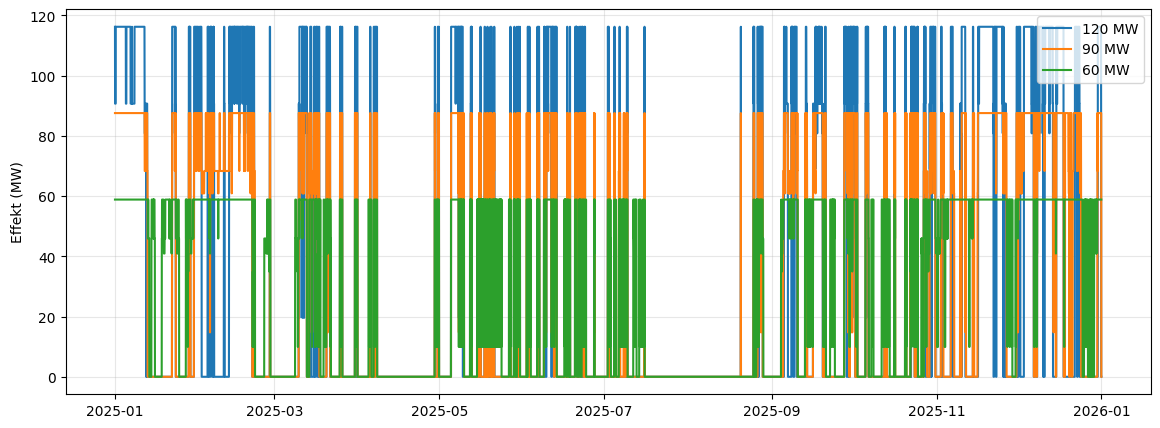

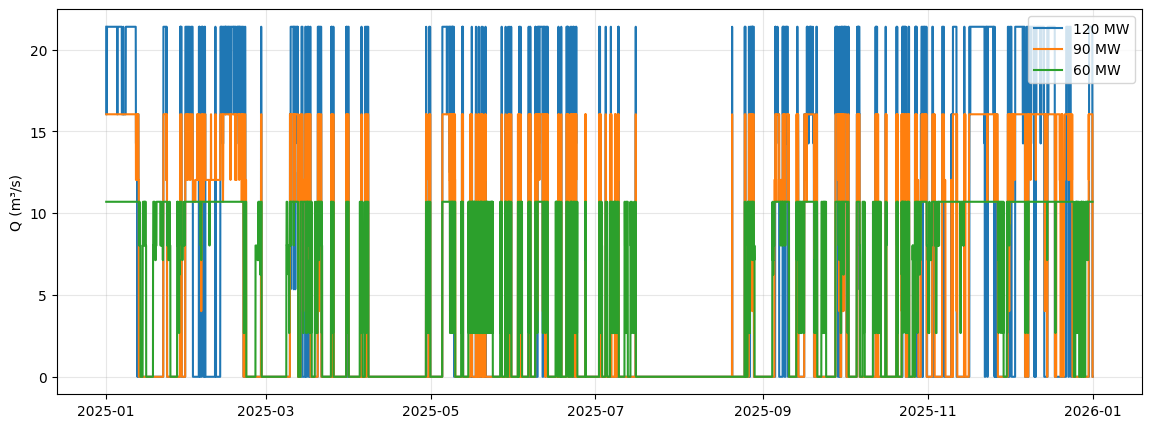

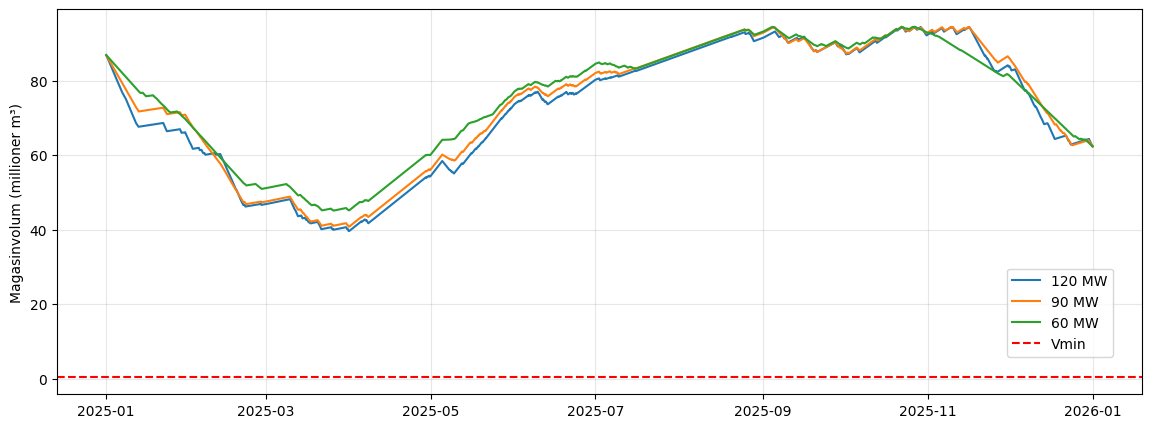

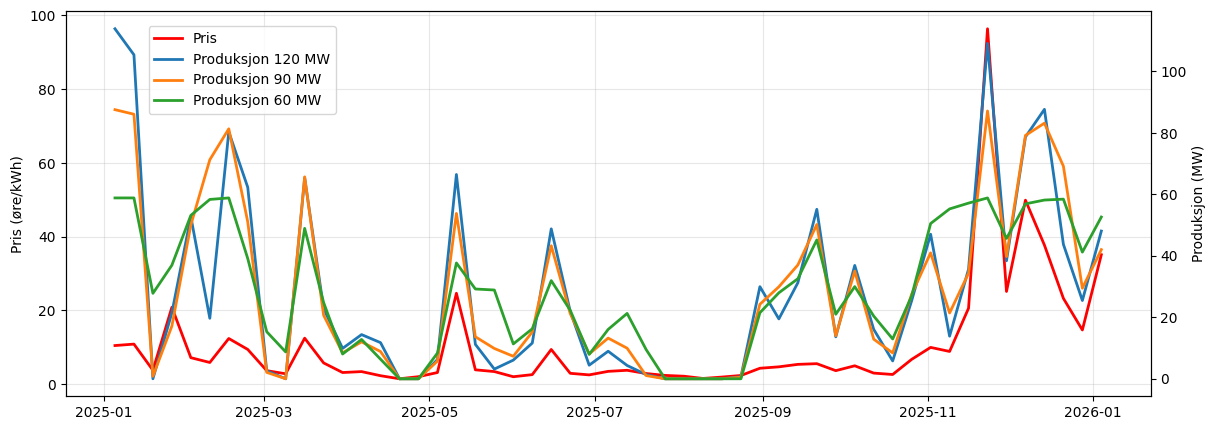

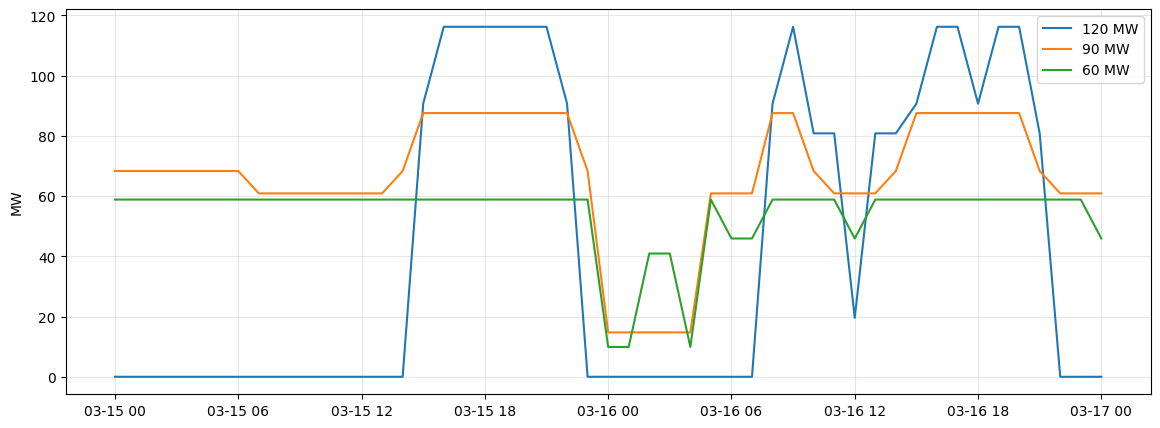

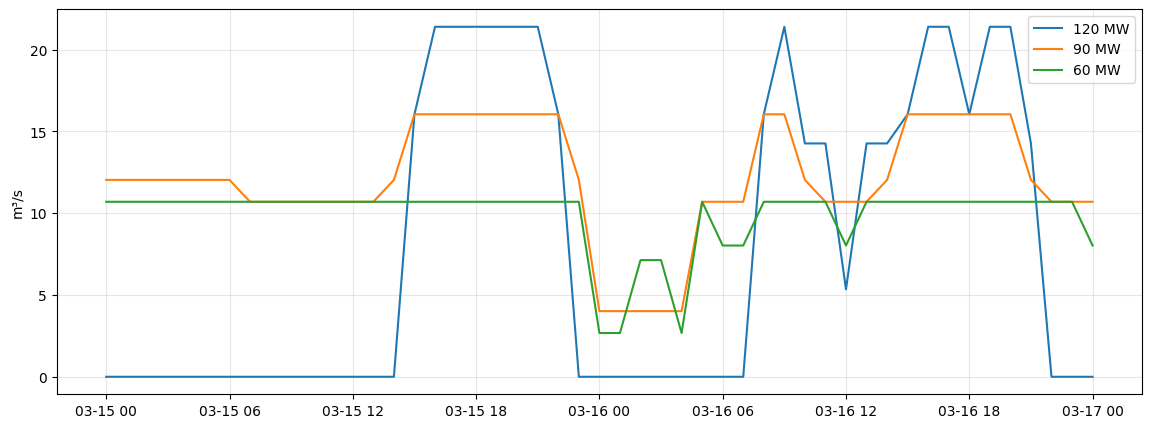

In [16]:
# PLOT

# 1. Produksjon
plt.figure(figsize=(14, 5))

plt.plot(results_120MW["Tid"], results_120MW["P_opt_MW"], label="120 MW")
plt.plot(results_90MW["Tid"], results_90MW["P_opt_MW"], label="90 MW")
plt.plot(results_60MW["Tid"], results_60MW["P_opt_MW"], label="60 MW")
plt.ylabel("Effekt (MW)")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")
plt.show()


# 2. Vannføring
plt.figure(figsize=(14, 5))
plt.plot(results_120MW["Tid"], results_120MW["Q_opt_m3s"], label="120 MW")
plt.plot(results_90MW["Tid"], results_90MW["Q_opt_m3s"], label="90 MW")
plt.plot(results_60MW["Tid"], results_60MW["Q_opt_m3s"], label="60 MW")
plt.ylabel("Q (m³/s)")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")
plt.show()


# 3. Magasin
plt.figure(figsize=(14, 5))
plt.plot(results_120MW["Tid"], results_120MW["Magasin_m3"] / 1e6, label="120 MW")
plt.plot(results_90MW["Tid"], results_90MW["Magasin_m3"] / 1e6, label="90 MW")
plt.plot(results_60MW["Tid"], results_60MW["Magasin_m3"] / 1e6, label="60 MW")
plt.axhline(Vmin / 1e6, color="red", linestyle="--", label="Vmin")
plt.ylabel("Magasinvolum (millioner m³)")
plt.grid(True, alpha=0.3)
plt.legend(loc="lower right", bbox_to_anchor=(0.98, 0.08))
plt.show()


# 4. Ukentlig gjennomsnitt av pris og produksjon
results_60_plot = results_60MW.set_index("Tid")
results_90_plot = results_90MW.set_index("Tid")
results_120_plot = results_120MW.set_index("Tid")

weekly_60 = results_60_plot.resample("W").mean(numeric_only=True)
weekly_90 = results_90_plot.resample("W").mean(numeric_only=True)
weekly_120 = results_120_plot.resample("W").mean(numeric_only=True)

plt.figure(figsize=(14, 5))

ax1 = plt.gca()
ax1.plot(weekly_60.index, weekly_60["Pris_ore_kWh"], label="Pris", linewidth=2, color="red")
ax1.set_ylabel("Pris (øre/kWh)")
ax1.grid(True, alpha=0.3)
ax2 = ax1.twinx()
ax2.plot(weekly_120.index, weekly_120["P_opt_MW"], label="Produksjon 120 MW", linewidth=2)
ax2.plot(weekly_90.index, weekly_90["P_opt_MW"], label="Produksjon 90 MW", linewidth=2)
ax2.plot(weekly_60.index, weekly_60["P_opt_MW"], label="Produksjon 60 MW", linewidth=2)
ax2.set_ylabel("Produksjon (MW)")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="upper left",
    bbox_to_anchor=(0.07, 0.98)
)

plt.show()




# Plot- forstørret i periode
start = "2025-03-15"
end = "2025-03-17"
mask_120 = (results_120MW["Tid"] >= start) & (results_120MW["Tid"] <= end)
mask_90 = (results_90MW["Tid"] >= start) & (results_90MW["Tid"] <= end)
mask_60 = (results_60MW["Tid"] >= start) & (results_60MW["Tid"] <= end)

subset_120 = results_120MW.loc[mask_120]
subset_90 = results_90MW.loc[mask_90]
subset_60 = results_60MW.loc[mask_60]

plt.figure(figsize=(14, 5))
plt.plot(subset_120["Tid"], subset_120["P_opt_MW"], label="120 MW")
plt.plot(subset_90["Tid"], subset_90["P_opt_MW"], label="90 MW")
plt.plot(subset_60["Tid"], subset_60["P_opt_MW"], label="60 MW")

plt.ylabel("MW")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()



start = "2025-03-15"
end = "2025-03-17"
mask_120 = (results_120MW["Tid"] >= start) & (results_120MW["Tid"] <= end)
mask_90 = (results_90MW["Tid"] >= start) & (results_90MW["Tid"] <= end)
mask_60 = (results_60MW["Tid"] >= start) & (results_60MW["Tid"] <= end)

subset_120 = results_120MW.loc[mask_120]
subset_90 = results_90MW.loc[mask_90]
subset_60 = results_60MW.loc[mask_60]

plt.figure(figsize=(14, 5))
plt.plot(subset_120["Tid"], subset_120["Q_opt_m3s"], label="120 MW")
plt.plot(subset_90["Tid"], subset_90["Q_opt_m3s"], label="90 MW")
plt.plot(subset_60["Tid"], subset_60["Q_opt_m3s"], label="60 MW")
plt.ylabel("m³/s")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()



In [3]:
#Grovt konstnadsestimat ved utbygging
#Kostnader ved utbygging til 90 MW
L_nytt_ror_90 = 100  #m
Pris_ror_90 = 20000  #kr

kostnad_nytt_ror_90 = L_nytt_ror_90 * Pris_ror_90


#Kostnader ved utbygging til 120 MW
L_nytt_ror_120 = 100  #m
Pris_ror_120 = 75000  #kr

kostnad_nytt_ror_120 = L_nytt_ror_120 * Pris_ror_120

#Elektronisk utstyr
Pris_elektronisk = 10000000 #kr

#Turbin
turbin_90 = 35100000   #kr
turbin_120 = 53700000  #kr

#Utløp
L_nytt_utlop = 120  #m
Pris_nytt_utlop = 24900 #kr/m
kostnad_nytt_utlop = L_nytt_utlop * Pris_nytt_utlop


#Totalt
installert_90 = kostnad_nytt_ror_90 + Pris_elektronisk + turbin_90
installert_120 = kostnad_nytt_ror_120 + Pris_elektronisk + turbin_120 + kostnad_nytt_utlop

print(f"Total kostnad for 90 MW: {installert_90:,.0f} kr")
print(f"Total kostnad for 120 MW: {installert_120:,.0f} kr")



Total kostnad for 90 MW: 47,100,000 kr
Total kostnad for 120 MW: 74,188,000 kr
